# Anxiety Risk — Python Robot interface Animation (Kaggle Notebook 4)

This notebook creates a **Reachy-inspired 2D/3D-style robot animation** around the anxiety-risk prediction pipeline. It is a visual simulation/interface, not a physical Reachy Mini or Webots simulation.

The existing project uses 12 features: Age, Gender, CGPA, Academic_Pressure, Financial_Stress, Study_Hours_Per_Day, Sleep_Duration, Social_Support, Exercise_Days_Per_Week, Diet_Quality, Family_History_Mental_Illness, and Perceived_Stress. The supplied Webots controller also describes low/mild/moderate/severe demo profiles and expects a trained `.keras` model plus preprocessing assets. fileciteturn1file0L50-L63 fileciteturn1file0L65-L100

**Important:** this notebook does not retrain the model. Upload the exact trained `federated_anxiety_model.keras` and its matching preprocessing file from your Kaggle training notebook.

In [23]:
# Cell 1 — install/verify packages
!pip -q install imageio imageio-ffmpeg joblib

import os, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, Ellipse, Arc, Rectangle
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import display, HTML, Image
import joblib

warnings.filterwarnings('ignore')
print('Python robot animation environment ready.')

Python robot animation environment ready.


## 1. Upload your trained model/assets

Use the upload cell below. The exact `.keras` model from your federated-learning notebook should be used; do not substitute a newly trained model if the thesis requires the original model.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, clear_output
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.20.0
NumPy: 2.1.3
Pandas: 2.2.3


# ============================================================
# CELL 2 — FIND ANXIETY ROBOT FILES
# ============================================================

In [26]:
# ============================================================
# CELL 2 — FIND ANXIETY ROBOT FILES
# ============================================================

import os

# Your actual Kaggle dataset folders
ROBOT_DIR = "/content/drive/MyDrive/ANIXETYDECPROJECT/data/anxiety robot data"
TEST_DIR  = "/content/drive/MyDrive/ANIXETYDECPROJECT/data/test data"

# Exact file paths
MODEL_PATH = os.path.join(
    ROBOT_DIR,
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/federated_anxiety_model.keras"
)

SCALER_PATH = os.path.join(
    ROBOT_DIR,
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/scaler.pkl"
)

METADATA_PATH = os.path.join(
    ROBOT_DIR,
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/feature_metadata.json"
)

CONTROLLER_PATH = os.path.join(
    ROBOT_DIR,
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/anxiety_controller.py"
)

CSV_PATH = os.path.join(
    TEST_DIR,
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/Anxiety.csv"
)

# ------------------------------------------------------------
# Check files
# ------------------------------------------------------------

files_to_check = {
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/anxiety_controller.py": CONTROLLER_PATH,
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/feature_metadata.json": METADATA_PATH,
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/federated_anxiety_model.keras": MODEL_PATH,
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/scaler.pkl": SCALER_PATH,
    "/content/drive/MyDrive/ANIXETYDECPROJECT/data/Anxiety.csv": CSV_PATH
}

print("=" * 70)
print("ANXIETY ROBOT — FILE CHECK")
print("=" * 70)

all_found = True

for filename, filepath in files_to_check.items():

    if os.path.isfile(filepath):
        print(f"✓ {filename}")
        print(f"  {filepath}")
    else:
        print(f"✗ {filename}")
        print(f"  NOT FOUND: {filepath}")
        all_found = False

print("=" * 70)

if all_found:
    print("✓ ALL REQUIRED FILES FOUND!")
else:
    print("✗ SOME FILES ARE MISSING.")

ANXIETY ROBOT — FILE CHECK
✓ /content/drive/MyDrive/ANIXETYDECPROJECT/data/anxiety_controller.py
  /content/drive/MyDrive/ANIXETYDECPROJECT/data/anxiety_controller.py
✓ /content/drive/MyDrive/ANIXETYDECPROJECT/data/feature_metadata.json
  /content/drive/MyDrive/ANIXETYDECPROJECT/data/feature_metadata.json
✓ /content/drive/MyDrive/ANIXETYDECPROJECT/data/federated_anxiety_model.keras
  /content/drive/MyDrive/ANIXETYDECPROJECT/data/federated_anxiety_model.keras
✓ /content/drive/MyDrive/ANIXETYDECPROJECT/data/scaler.pkl
  /content/drive/MyDrive/ANIXETYDECPROJECT/data/scaler.pkl
✓ /content/drive/MyDrive/ANIXETYDECPROJECT/data/Anxiety.csv
  /content/drive/MyDrive/ANIXETYDECPROJECT/data/Anxiety.csv
✓ ALL REQUIRED FILES FOUND!


# ============================================================
# CELL 3 — VERIFY FILE PATHS
# ============================================================

In [27]:
# ============================================================
# CELL 3 — VERIFY FILE PATHS
# ============================================================

required_files = [
    MODEL_PATH,
    SCALER_PATH,
    METADATA_PATH,
    CONTROLLER_PATH,
    CSV_PATH
]

for path in required_files:

    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"\nFILE NOT FOUND:\n{path}\n\n"
            "Please check that the ZIP files are correctly placed "
            "in Google Drive and extracted successfully."
        )

print("=" * 70)
print("ANXIETY ROBOT — FILE PATH VERIFICATION")
print("=" * 70)

print("✓ Model       :", MODEL_PATH)
print("✓ Scaler      :", SCALER_PATH)
print("✓ Metadata    :", METADATA_PATH)
print("✓ Controller  :", CONTROLLER_PATH)
print("✓ Test Data   :", CSV_PATH)

print("=" * 70)
print("\n✓ All files verified successfully!")
print("✓ Google Drive files are ready for use.")

ANXIETY ROBOT — FILE PATH VERIFICATION
✓ Model       : /content/drive/MyDrive/ANIXETYDECPROJECT/data/federated_anxiety_model.keras
✓ Scaler      : /content/drive/MyDrive/ANIXETYDECPROJECT/data/scaler.pkl
✓ Metadata    : /content/drive/MyDrive/ANIXETYDECPROJECT/data/feature_metadata.json
✓ Controller  : /content/drive/MyDrive/ANIXETYDECPROJECT/data/anxiety_controller.py
✓ Test Data   : /content/drive/MyDrive/ANIXETYDECPROJECT/data/Anxiety.csv

✓ All files verified successfully!
✓ Google Drive files are ready for use.


In [28]:
# ============================================================
# CELL 3 — VERIFY FILE PATHS
# ============================================================

required_files = [
    MODEL_PATH,
    SCALER_PATH,
    METADATA_PATH,
    CONTROLLER_PATH,
    CSV_PATH
]

for path in required_files:
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"\nFILE NOT FOUND:\n{path}\n\n"
            "Please check that the correct Kaggle dataset is attached."
        )

print("✓ Model       :", MODEL_PATH)
print("✓ Scaler      :", SCALER_PATH)
print("✓ Metadata    :", METADATA_PATH)
print("✓ Controller  :", CONTROLLER_PATH)
print("✓ Test Data   :", CSV_PATH)

print("\n✓ All files verified successfully.")

✓ Model       : /content/drive/MyDrive/ANIXETYDECPROJECT/data/federated_anxiety_model.keras
✓ Scaler      : /content/drive/MyDrive/ANIXETYDECPROJECT/data/scaler.pkl
✓ Metadata    : /content/drive/MyDrive/ANIXETYDECPROJECT/data/feature_metadata.json
✓ Controller  : /content/drive/MyDrive/ANIXETYDECPROJECT/data/anxiety_controller.py
✓ Test Data   : /content/drive/MyDrive/ANIXETYDECPROJECT/data/Anxiety.csv

✓ All files verified successfully.


# ============================================================
# CELL 4 — LOAD ANXIETY TEST DATA
# ============================================================


In [29]:
# ============================================================
# CELL 4 — LOAD ANXIETY TEST DATA
# ============================================================

import pandas as pd

df = pd.read_csv(CSV_PATH)

print("=" * 70)
print("ANXIETY TEST DATA")
print("=" * 70)

print("Dataset shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

print("\nFirst 5 rows:")
display(df.head())

ANXIETY TEST DATA
Dataset shape: (2028, 16)

Columns:
0: Age
1: Gender
2: University
3: Department
4: Academic Year
5: Current CGPA
6: Did you receive a waiver or scholarship at your university?
7: 1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? 
8: 2. In a semester, how often have you been unable to stop worrying about your academic affairs? 
9: 3. In a semester, how often have you had trouble relaxing due to academic pressure? 
10: 4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?
11: 5. In a semester, how often have you worried too much about academic affairs? 
12: 6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?
13: 7. In a semester, how often have you felt afraid, as if something awful might happen?
14: Anxiety Value
15: Anxiety Label

First 5 rows:


,Age,Gender,University,Department,Academic Year,Current CGPA,Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value,Anxiety Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,2,2,3,2,2,2,2,15,Severe Anxiety
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,1,2,2,1,1,3,2,12,Moderate Anxiety
2,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,0,0,0,0,0,0,0,0,Minimal Anxiety
3,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,2,1,1,1,2,1,2,10,Moderate Anxiety
4,18-22,Male,North South University (NSU),Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,3,0,3,3,1,1,3,14,Moderate Anxiety


# ============================================================
# CELL 5 — LOAD FEATURE METADATA
# ============================================================

In [30]:
# ============================================================
# CELL 6 — LOAD FEATURE METADATA
# ============================================================

import json

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print("=" * 70)
print("FEATURE METADATA LOADED")
print("=" * 70)

print(json.dumps(metadata, indent=4))

FEATURE METADATA LOADED
{
    "target": "Anxiety_Risk",
    "features": [
        "Age",
        "Gender",
        "CGPA",
        "Academic_Pressure",
        "Financial_Stress",
        "Study_Hours_Per_Day",
        "Sleep_Duration",
        "Social_Support",
        "Exercise_Days_Per_Week",
        "Diet_Quality",
        "Family_History_Mental_Illness",
        "Perceived_Stress"
    ],
    "model_type": "TensorFlow Keras Federated Learning Model",
    "prediction_type": "Binary Anxiety Risk",
    "classes": {
        "0": "Low Anxiety Risk",
        "1": "High Anxiety Risk"
    },
    "federated_clients": 5,
    "communication_rounds": 5
}


# ============================================================
# CELL 6 — LOAD SCALER (FIXED)
# ============================================================

In [31]:
# ============================================================
# CELL 7 — LOAD SCALER (FIXED)
# ============================================================

import pickle
import joblib
import os

print("=" * 70)
print("LOADING SCALER")
print("=" * 70)

print("Scaler file:")
print(SCALER_PATH)

print("\nFile size:",
      round(os.path.getsize(SCALER_PATH) / 1024, 2),
      "KB")

scaler = None

# ------------------------------------------------------------
# METHOD 1 — joblib
# ------------------------------------------------------------

try:
    print("\nTrying joblib.load() ...")

    scaler = joblib.load(SCALER_PATH)

    print("✓ Scaler loaded successfully using joblib.")

except Exception as e:

    print("✗ joblib failed:")
    print(type(e).__name__, ":", str(e))

# ------------------------------------------------------------
# METHOD 2 — standard pickle
# ------------------------------------------------------------

if scaler is None:

    try:
        print("\nTrying pickle.load() ...")

        with open(SCALER_PATH, "rb") as f:
            scaler = pickle.load(f)

        print("✓ Scaler loaded successfully using pickle.")

    except Exception as e:

        print("✗ pickle failed:")
        print(type(e).__name__, ":", str(e))

# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

if scaler is None:

    raise RuntimeError(
        """
Unable to load scaler.pkl using joblib or pickle.

The file may have been created with a different serialization
method/version. We need to inspect how the original scaler was saved.
"""
    )

print("\n" + "=" * 70)
print("SCALER INFORMATION")
print("=" * 70)

print("Scaler type:", type(scaler))

if hasattr(scaler, "n_features_in_"):
    print(
        "Number of features expected:",
        scaler.n_features_in_
    )

if hasattr(scaler, "feature_names_in_"):

    print("\nScaler feature names:")

    for i, feature in enumerate(
        scaler.feature_names_in_
    ):
        print(f"{i+1}. {feature}")

print("\n✓ SCALER READY")

LOADING SCALER
Scaler file:
/content/drive/MyDrive/ANIXETYDECPROJECT/data/scaler.pkl

File size: 4.49 KB

Trying joblib.load() ...
✓ Scaler loaded successfully using joblib.

SCALER INFORMATION
Scaler type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Number of features expected: 15

Scaler feature names:
1. Age
2. Gender
3. University
4. Department
5. Academic Year
6. Current CGPA
7. Did you receive a waiver or scholarship at your university?
8. 1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? 
9. 2. In a semester, how often have you been unable to stop worrying about your academic affairs? 
10. 3. In a semester, how often have you had trouble relaxing due to academic pressure? 
11. 4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?
12. 5. In a semester, how often have you worried too much about academic affairs? 
13. 6. In a semester, how often have you been so restless due t

# ============================================================
# CELL 7 — LOAD FEDERATED ANXIETY MODEL
# ============================================================

In [32]:
# ============================================================
# CELL 8 — LOAD FEDERATED ANXIETY MODEL
# ============================================================

import tensorflow as tf

print("=" * 70)
print("LOADING FEDERATED ANXIETY MODEL")
print("=" * 70)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("\n✓ MODEL LOADED SUCCESSFULLY")

print("\nModel input shape :", model.input_shape)
print("Model output shape:", model.output_shape)

print("\nModel Summary:")
model.summary()

LOADING FEDERATED ANXIETY MODEL

✓ MODEL LOADED SUCCESSFULLY

Model input shape : (None, 15)
Model output shape: (None, 4)

Model Summary:


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_104 (Dense)               │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,516 (48.89 KB)

 Trainable params: 12,516 (48.89 KB)

 Non-trainable params: 0 (0.00 B)

# ============================================================
# CELL 8 — DETECT MODEL FEATURES
# ============================================================

In [33]:
# ============================================================
# CELL 8 — DETECT MODEL FEATURES
# ============================================================

print("=" * 70)
print("FEATURE DETECTION")
print("=" * 70)

feature_columns = None

# ------------------------------------------------------------
# 1. Try scaler feature names
# ------------------------------------------------------------

if hasattr(scaler, "feature_names_in_"):

    feature_columns = list(scaler.feature_names_in_)

    print("✓ Features obtained from scaler.")

# ------------------------------------------------------------
# 2. Try feature metadata
# ------------------------------------------------------------

if feature_columns is None and isinstance(metadata, dict):

    possible_keys = [
        "features",
        "feature_names",
        "selected_features",
        "input_features",
        "columns"
    ]

    for key in possible_keys:

        if key in metadata:

            value = metadata[key]

            if isinstance(value, list):

                feature_columns = value

                print(
                    f"✓ Features obtained from metadata key: '{key}'"
                )

                break

# ------------------------------------------------------------
# 3. Fallback
# ------------------------------------------------------------

if feature_columns is None:

    feature_columns = list(
        df.select_dtypes(include=np.number).columns
    )

    print(
        "⚠ No explicit feature list found."
    )

    print(
        "Using numerical columns from Anxiety.csv."
    )

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nSelected Features:")

for i, col in enumerate(feature_columns):

    print(f"{i+1}. {col}")

print(
    "\nTotal selected features:",
    len(feature_columns)
)

print(
    "Model expects:",
    model.input_shape[-1],
    "features"
)

FEATURE DETECTION
✓ Features obtained from scaler.

Selected Features:
1. Age
2. Gender
3. University
4. Department
5. Academic Year
6. Current CGPA
7. Did you receive a waiver or scholarship at your university?
8. 1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? 
9. 2. In a semester, how often have you been unable to stop worrying about your academic affairs? 
10. 3. In a semester, how often have you had trouble relaxing due to academic pressure? 
11. 4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?
12. 5. In a semester, how often have you worried too much about academic affairs? 
13. 6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?
14. 7. In a semester, how often have you felt afraid, as if something awful might happen?
15. Anxiety Value

Total selected features: 15
Model expects: 15 features


# ============================================================
# CELL 9 — CHECK FEATURES AGAINST CSV
# ============================================================

In [34]:
# ============================================================
# CELL 9 — CHECK FEATURES AGAINST CSV
# ============================================================

csv_columns = set(df.columns)

missing_features = [
    col for col in feature_columns
    if col not in csv_columns
]

available_features = [
    col for col in feature_columns
    if col in csv_columns
]

print("=" * 70)
print("FEATURE COMPATIBILITY")
print("=" * 70)

print("Required features :", len(feature_columns))
print("Available features:", len(available_features))
print("Missing features  :", len(missing_features))

if missing_features:

    print("\n❌ MISSING FEATURES:")

    for col in missing_features:
        print(" -", col)

else:

    print("\n✓ ALL REQUIRED FEATURES ARE PRESENT")

FEATURE COMPATIBILITY
Required features : 15
Available features: 15
Missing features  : 0

✓ ALL REQUIRED FEATURES ARE PRESENT


# ============================================================
# CELL 10 — PREPARE MODEL INPUT
# ============================================================

In [35]:
# ============================================================
# CELL 10 — PREPARE MODEL INPUT
# ============================================================

if missing_features:

    raise ValueError(
        "Some model features are missing from Anxiety.csv. "
        "Please inspect Cell 10."
    )

X = df[feature_columns].copy()

print("=" * 70)
print("MODEL INPUT")
print("=" * 70)

print("X shape:", X.shape)

display(X.head())

MODEL INPUT
X shape: (2028, 15)


,Age,Gender,University,Department,Academic Year,Current CGPA,Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,2,2,3,2,2,2,2,15
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,1,2,2,1,1,3,2,12
2,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,0,0,0,0,0,0,0,0
3,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,2,1,1,1,2,1,2,10
4,18-22,Male,North South University (NSU),Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,3,0,3,3,1,1,3,14


# ============================================================
# CELL 11 — ROBUST MISSING VALUE HANDLING
# ============================================================

In [36]:
# ============================================================
# CELL 11 — ROBUST MISSING VALUE HANDLING
# ============================================================

print("=" * 70)
print("ROBUST DATA CLEANING")
print("=" * 70)

X = df[feature_columns].copy()

# ------------------------------------------------------------
# Convert all selected features to numeric
# ------------------------------------------------------------

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

print("\nMissing values BEFORE cleaning:")
display(X.isna().sum().sort_values(ascending=False))

# ------------------------------------------------------------
# Replace infinite values
# ------------------------------------------------------------

X = X.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# Median imputation
# ------------------------------------------------------------

for col in X.columns:

    if X[col].isna().all():

        print(
            f"WARNING: {col} contains ONLY missing values."
        )

    else:

        median_value = X[col].median()

        X[col] = X[col].fillna(median_value)

# ------------------------------------------------------------
# Final fallback
# ------------------------------------------------------------

X = X.fillna(0)

# ------------------------------------------------------------
# Check
# ------------------------------------------------------------

print("\nMissing values AFTER cleaning:")
display(X.isna().sum().sort_values(ascending=False))

print(
    "\nTotal NaN:",
    X.isna().sum().sum()
)

print(
    "Total INF:",
    np.isinf(
        X.to_numpy(dtype=float)
    ).sum()
)

print("\n✓ CLEANING COMPLETED")

ROBUST DATA CLEANING

Missing values BEFORE cleaning:


,0
Age,2028
Gender,2028
University,2028
Department,2028
Academic Year,2028
Current CGPA,2028
Did you receive a waiver or scholarship at your university?,2028
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",0
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",0
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",0



Missing values AFTER cleaning:


,0
Age,0
Gender,0
University,0
Department,0
Academic Year,0
Current CGPA,0
Did you receive a waiver or scholarship at your university?,0
"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?",0
"2. In a semester, how often have you been unable to stop worrying about your academic affairs?",0
"3. In a semester, how often have you had trouble relaxing due to academic pressure?",0



Total NaN: 0
Total INF: 0

✓ CLEANING COMPLETED


# ============================================================
# CELL 12 — APPLY ORIGINAL SCALER
# ============================================================

In [37]:
# ============================================================
# CELL 12 — APPLY ORIGINAL SCALER
# ============================================================

X_scaled = scaler.transform(X)

X_scaled = np.asarray(X_scaled)

print("=" * 70)
print("SCALING COMPLETED")
print("=" * 70)

print("Original shape:", X.shape)
print("Scaled shape  :", X_scaled.shape)

print("NaN values:", np.isnan(X_scaled).sum())
print("INF values:", np.isinf(X_scaled).sum())

print("\n✓ Scaling completed.")

SCALING COMPLETED
Original shape: (2028, 15)
Scaled shape  : (2028, 15)
NaN values: 0
INF values: 0

✓ Scaling completed.


# ============================================================
# CELL 13 — FINAL MODEL INPUT CHECK
# ============================================================

In [38]:
# ============================================================
# CELL 13 — FINAL MODEL INPUT CHECK
# ============================================================

expected_features = model.input_shape[-1]
actual_features = X_scaled.shape[1]

print("=" * 70)
print("FINAL MODEL INPUT VALIDATION")
print("=" * 70)

print("Model expects :", expected_features)
print("Data provides :", actual_features)

if expected_features != actual_features:

    raise ValueError(
        f"""
FEATURE COUNT MISMATCH!

Model expects {expected_features} features,
but prepared data contains {actual_features}.
"""
    )

print("\n✓ PERFECT MATCH!")
print("✓ READY FOR ANXIETY PREDICTION")

FINAL MODEL INPUT VALIDATION
Model expects : 15
Data provides : 15

✓ PERFECT MATCH!
✓ READY FOR ANXIETY PREDICTION


# ============================================================
# CELL 14 — RUN MODEL AGAIN
# ============================================================

In [39]:
# ============================================================
# CELL 14 — RUN MODEL AGAIN
# ============================================================

predictions = model.predict(
    X_scaled,
    verbose=0
)

print("=" * 70)
print("NEW MODEL PREDICTION")
print("=" * 70)

print("Prediction shape:", predictions.shape)

print("\nFirst 10 predictions:")
display(predictions[:10])

print(
    "\nNaN count:",
    np.isnan(predictions).sum()
)

print(
    "INF count:",
    np.isinf(predictions).sum()
)

NEW MODEL PREDICTION
Prediction shape: (2028, 4)

First 10 predictions:


array([[9.82532611e-10, 5.26256573e-15, 1.53741255e-01, 8.46258640e-01],
       [1.41145865e-05, 2.65312663e-12, 9.99979675e-01, 6.15098224e-06],
       [2.53710168e-05, 9.99974549e-01, 2.55417839e-14, 8.50397892e-16],
       [1.77189820e-02, 4.63829437e-08, 9.82271373e-01, 9.48829893e-06],
       [1.70598806e-08, 1.62730140e-14, 9.87689376e-01, 1.23105748e-02],
       [9.94279027e-01, 5.71627263e-03, 4.71185604e-06, 4.42387210e-10],
       [9.32297707e-01, 6.77016973e-02, 5.90526611e-07, 1.52129448e-10],
       [7.27378309e-01, 2.72621483e-01, 5.69877159e-08, 1.98834560e-11],
       [1.83819751e-07, 1.44906819e-13, 9.99858379e-01, 1.41339464e-04],
       [9.95560884e-01, 4.43208637e-03, 6.90874231e-06, 8.69722072e-10]],
      dtype=float32)


NaN count: 0
INF count: 0


# ============================================================
# CELL 15 — INSPECT 4-CLASS MODEL OUTPUT
# ============================================================

In [40]:
# ============================================================
# CELL 15 — INSPECT 4-CLASS MODEL OUTPUT
# ============================================================

print("=" * 70)
print("4-CLASS MODEL OUTPUT")
print("=" * 70)

print("Prediction shape:", predictions.shape)

# Check probability values
print("\nFirst 10 prediction rows:")
display(
    pd.DataFrame(
        predictions[:10],
        columns=[
            "Class_0",
            "Class_1",
            "Class_2",
            "Class_3"
        ]
    )
)

print("\nRow sums:")
print(
    predictions[:10].sum(axis=1)
)

print("\nMinimum prediction value:",
      predictions.min())

print("Maximum prediction value:",
      predictions.max())

4-CLASS MODEL OUTPUT
Prediction shape: (2028, 4)

First 10 prediction rows:


,Class_0,Class_1,Class_2,Class_3
0,9.825326e-10,5.262566e-15,1.537413e-01,8.462586e-01
1,1.411459e-05,2.653127e-12,9.999797e-01,6.150982e-06
2,2.537102e-05,9.999745e-01,2.554178e-14,8.503979e-16
3,1.771898e-02,4.638294e-08,9.822714e-01,9.488299e-06
4,1.705988e-08,1.627301e-14,9.876894e-01,1.231057e-02
5,9.942790e-01,5.716273e-03,4.711856e-06,4.423872e-10
6,9.322977e-01,6.770170e-02,5.905266e-07,1.521294e-10
7,7.273783e-01,2.726215e-01,5.698772e-08,1.988346e-11
8,1.838198e-07,1.449068e-13,9.998584e-01,1.413395e-04
9,9.955609e-01,4.432086e-03,6.908742e-06,8.697221e-10



Row sums:
[0.9999999  0.99999994 0.99999994 0.9999999  0.99999994 1.
 1.         0.9999998  0.9999999  0.9999999 ]

Minimum prediction value: 1.0566445e-32
Maximum prediction value: 1.0


# ============================================================
# CELL 16 — FIND CLASS LABELS
# ============================================================

In [41]:
# ============================================================
# CELL 16 — FIND CLASS LABELS
# ============================================================

print("=" * 70)
print("SEARCHING FOR CLASS LABELS")
print("=" * 70)

def find_label_information(obj, path="metadata"):

    if isinstance(obj, dict):

        for key, value in obj.items():

            key_lower = str(key).lower()

            if any(word in key_lower for word in [
                "class",
                "label",
                "target",
                "category",
                "output",
                "mapping"
            ]):

                print(f"\n{path}.{key}")
                print("-" * 50)
                print(value)

            find_label_information(
                value,
                f"{path}.{key}"
            )

    elif isinstance(obj, list):

        for i, value in enumerate(obj):

            find_label_information(
                value,
                f"{path}[{i}]"
            )


find_label_information(metadata)

SEARCHING FOR CLASS LABELS

metadata.target
--------------------------------------------------
Anxiety_Risk

metadata.classes
--------------------------------------------------
{'0': 'Low Anxiety Risk', '1': 'High Anxiety Risk'}


# ============================================================
# CELL 17 — INSPECT OUTPUT LAYER
# ============================================================

In [42]:
# ============================================================
# CELL 17 — INSPECT OUTPUT LAYER
# ============================================================

print("=" * 70)
print("MODEL OUTPUT LAYER")
print("=" * 70)

output_layer = model.layers[-1]

print("Layer name :", output_layer.name)
print("Layer type :", type(output_layer).__name__)

print("\nActivation:")

if hasattr(output_layer, "activation"):
    print(
        output_layer.activation.__name__
    )
else:
    print("No activation attribute found.")

print("\nOutput units:")

if hasattr(output_layer, "units"):
    print(output_layer.units)

MODEL OUTPUT LAYER
Layer name : dense_107
Layer type : Dense

Activation:
softmax

Output units:
4


# ============================================================
# CELL 18 — PREDICTED CLASS
# ============================================================

In [43]:
# ============================================================
# CELL 18 — PREDICTED CLASS
# ============================================================

predicted_class = np.argmax(
    predictions,
    axis=1
)

confidence = np.max(
    predictions,
    axis=1
)

class_results = pd.DataFrame({
    "Predicted_Class": predicted_class,
    "Confidence": confidence
})

print("=" * 70)
print("PREDICTED CLASSES")
print("=" * 70)

display(
    class_results.head(20)
)

print("\nClass distribution:")

display(
    class_results[
        "Predicted_Class"
    ].value_counts().sort_index()
)

PREDICTED CLASSES


,Predicted_Class,Confidence
0,3,0.846259
1,2,0.999980
2,1,0.999975
3,2,0.982271
4,2,0.987689
5,0,0.994279
6,0,0.932298
7,0,0.727378
8,2,0.999858
9,0,0.995561



Class distribution:


,count
Predicted_Class,
0,510
1,150
2,632
3,736


# ============================================================
# CELL 19 — FOUR CLASS DISTRIBUTION
# ============================================================

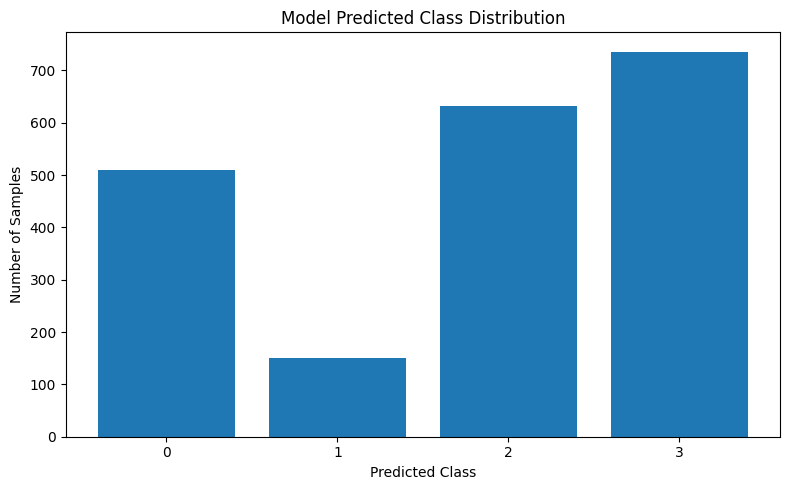

In [44]:
# ============================================================
# CELL 19 — FOUR CLASS DISTRIBUTION
# ============================================================

class_counts = (
    pd.Series(predicted_class)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title(
    "Model Predicted Class Distribution"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Number of Samples"
)

plt.tight_layout()

plt.show()

# ============================================================
# CELL 20 — COMPLETE MODEL OUTPUT TABLE
# ============================================================

In [45]:
# ============================================================
# CELL 20 — COMPLETE MODEL OUTPUT TABLE
# ============================================================

results = df.copy()

results["Class_0_Probability"] = predictions[:, 0]
results["Class_1_Probability"] = predictions[:, 1]
results["Class_2_Probability"] = predictions[:, 2]
results["Class_3_Probability"] = predictions[:, 3]

results["Predicted_Class"] = predicted_class

results["Prediction_Confidence"] = confidence

print("=" * 70)
print("COMPLETE PREDICTION RESULTS")
print("=" * 70)

display(
    results.head(5)
)

COMPLETE PREDICTION RESULTS


,Age,Gender,University,Department,Academic Year,Current CGPA,Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?",...,"6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value,Anxiety Label,Class_0_Probability,Class_1_Probability,Class_2_Probability,Class_3_Probability,Predicted_Class,Prediction_Confidence
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,2,2,3,...,2,2,15,Severe Anxiety,9.825326e-10,5.262566e-15,1.537413e-01,8.462586e-01,3,0.846259
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,1,2,2,...,3,2,12,Moderate Anxiety,1.411459e-05,2.653127e-12,9.999797e-01,6.150982e-06,2,0.999980
2,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,0,0,0,...,0,0,0,Minimal Anxiety,2.537102e-05,9.999745e-01,2.554178e-14,8.503979e-16,1,0.999975
3,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,2,1,1,...,1,2,10,Moderate Anxiety,1.771898e-02,4.638294e-08,9.822714e-01,9.488299e-06,2,0.982271
4,18-22,Male,North South University (NSU),Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,3,0,3,...,1,3,14,Moderate Anxiety,1.705988e-08,1.627301e-14,9.876894e-01,1.231057e-02,2,0.987689


# ============================================================
# CELL 21 — ANXIETY SCORE + LEVEL
# ============================================================

In [46]:
# ============================================================
# CELL 21 — ANXIETY SCORE + LEVEL
# ============================================================

# Class interpretation from the existing controller:
# Class 0 = Minimal / Low
# Class 1 = Mild
# Class 2 = Moderate
# Class 3 = Severe / High

class_names = {
    0: "LOW",
    1: "MILD",
    2: "MODERATE",
    3: "HIGH"
}

# Weighted anxiety score
# 0 = Low
# 1 = Mild
# 2 = Moderate
# 3 = High

class_weights = np.array([
    0.00,
    0.33,
    0.66,
    1.00
])

# Calculate anxiety score
anxiety_scores = (
    predictions @ class_weights
) * 100

# Most likely class
predicted_class = np.argmax(
    predictions,
    axis=1
)

# Convert to 3 main robot states
def get_robot_level(score):

    if score < 33:
        return "LOW"

    elif score < 66:
        return "MODERATE"

    else:
        return "HIGH"


robot_levels = [
    get_robot_level(score)
    for score in anxiety_scores
]

# Add to results
results = df.copy()

results["Anxiety_Score"] = anxiety_scores
results["Predicted_Class"] = predicted_class
results["Model_Class"] = [
    class_names[c]
    for c in predicted_class
]
results["Robot_Level"] = robot_levels

print("=" * 70)
print("ANXIETY LEVEL CALCULATION")
print("=" * 70)

display(
    results[
        [
            "Anxiety_Score",
            "Predicted_Class",
            "Model_Class",
            "Robot_Level"
        ]
    ].head(20)
)

ANXIETY LEVEL CALCULATION


,Anxiety_Score,Predicted_Class,Model_Class,Robot_Level
0,94.772787,3,HIGH,HIGH
1,65.999274,2,MODERATE,MODERATE
2,32.999160,1,MILD,LOW
3,64.830861,2,MODERATE,MODERATE
4,66.418556,2,MODERATE,HIGH
5,0.188948,0,LOW,LOW
6,2.234195,0,LOW,LOW
7,8.996513,0,LOW,LOW
8,66.004787,2,MODERATE,HIGH
9,0.146715,0,LOW,LOW


# ============================================================
# CELL 22 — ANXIETY LEVEL DISTRIBUTION
# ============================================================

ANXIETY LEVEL DISTRIBUTION
LOW      : 660
MODERATE : 314
HIGH     : 1054


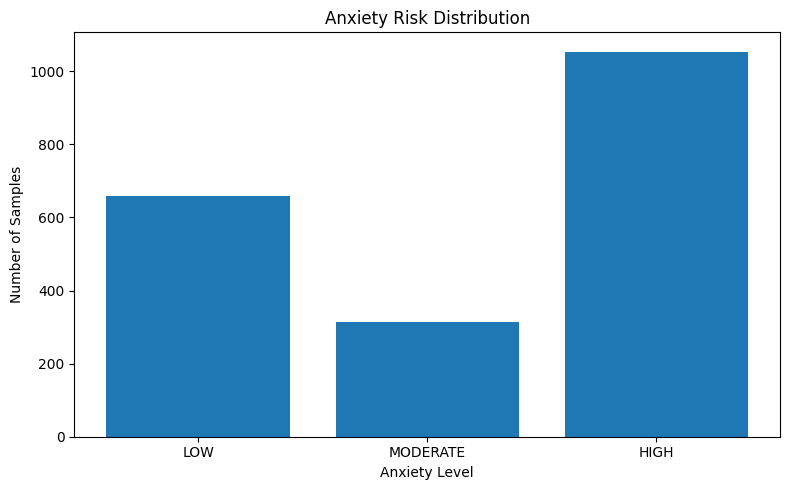

In [47]:
# ============================================================
# CELL 22 — ANXIETY LEVEL DISTRIBUTION
# ============================================================

print("=" * 70)
print("ANXIETY LEVEL DISTRIBUTION")
print("=" * 70)

level_counts = (
    results["Robot_Level"]
    .value_counts()
)

print(
    "LOW      :",
    level_counts.get("LOW", 0)
)

print(
    "MODERATE :",
    level_counts.get("MODERATE", 0)
)

print(
    "HIGH     :",
    level_counts.get("HIGH", 0)
)

plt.figure(figsize=(8, 5))

plt.bar(
    ["LOW", "MODERATE", "HIGH"],
    [
        level_counts.get("LOW", 0),
        level_counts.get("MODERATE", 0),
        level_counts.get("HIGH", 0)
    ]
)

plt.title(
    "Anxiety Risk Distribution"
)

plt.xlabel(
    "Anxiety Level"
)

plt.ylabel(
    "Number of Samples"
)

plt.tight_layout()

plt.show()

# ============================================================
# CELL 23 — SELECT STUDENT / TEST SAMPLE
# ============================================================

In [48]:
# ============================================================
# CELL 23 — SELECT STUDENT / TEST SAMPLE
# ============================================================

sample_index = 0

if sample_index < 0 or sample_index >= len(results):

    raise IndexError(
        "Invalid sample_index."
    )

selected_score = float(
    anxiety_scores[sample_index]
)

selected_level = robot_levels[
    sample_index
]

selected_class = int(
    predicted_class[sample_index]
)

print("=" * 70)
print("SELECTED ANXIETY ASSESSMENT")
print("=" * 70)

print(
    "Sample:",
    sample_index + 1
)

print(
    "Anxiety Score:",
    f"{selected_score:.1f}/100"
)

print(
    "Anxiety Level:",
    selected_level
)

print(
    "Model Class:",
    class_names[selected_class]
)

SELECTED ANXIETY ASSESSMENT
Sample: 1
Anxiety Score: 94.8/100
Anxiety Level: HIGH
Model Class: HIGH


# Reachy mini Robot Animate Simulation

In [49]:
# ============================================================
# FINAL ROBOT ANIMATION
# Shows LOW + MODERATE + HIGH samples
# ============================================================

# ------------------------------------------------------------
# Required imports
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# ============================================================
# ROBOT DRAWING FUNCTION
# ============================================================

def draw_robot_all_samples(
    ax,
    score,
    level,
    sample_number,
    frame
):
    """
    Draw the Reachy-style robot visualization
    for LOW, MODERATE and HIGH anxiety levels.
    """

    # --------------------------------------------------------
    # Clear previous frame
    # --------------------------------------------------------

    ax.clear()

    ax.set_xlim(-6, 6)
    ax.set_ylim(-7, 8)

    ax.set_aspect("equal")
    ax.axis("off")


    # --------------------------------------------------------
    # Normalize level
    # --------------------------------------------------------

    level = str(level).upper()


    # --------------------------------------------------------
    # Determine robot state
    # --------------------------------------------------------

    if level == "LOW":

        robot_color = "green"
        status_text = "LOW ANXIETY"
        eye_color = "green"

    elif level == "MODERATE":

        robot_color = "orange"
        status_text = "MODERATE ANXIETY"
        eye_color = "yellow"

    else:

        robot_color = "red"
        status_text = "HIGH ANXIETY"
        eye_color = "red"


    # ========================================================
    # TITLE
    # ========================================================

    ax.text(
        0,
        7.4,
        "Reachy Mini Anxiety Risk Robot",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold"
    )


    # ========================================================
    # SAMPLE NUMBER
    # ========================================================

    ax.text(
        0,
        6.75,
        f"Sample {sample_number}",
        ha="center",
        va="center",
        fontsize=11
    )


    # ========================================================
    # HEAD MOVEMENT
    # ========================================================

    # Small left-right head movement
    head_shift = 0.15 * (
        (frame % 12) / 6 - 1
    )


    # ========================================================
    # HEAD
    # ========================================================

    head = patches.FancyBboxPatch(
        (
            -2.3 + head_shift,
            2.0
        ),
        4.6,
        3.0,
        boxstyle="round,pad=0.25",
        linewidth=2
    )

    ax.add_patch(head)


    # ========================================================
    # LEFT EYE
    # ========================================================

    left_eye = patches.Ellipse(
        (
            -1.15 + head_shift,
            3.45
        ),
        0.65,
        0.85,
        linewidth=2,
        facecolor=eye_color
    )

    ax.add_patch(left_eye)


    # ========================================================
    # RIGHT EYE
    # ========================================================

    right_eye = patches.Ellipse(
        (
            1.15 + head_shift,
            3.45
        ),
        0.65,
        0.85,
        linewidth=2,
        facecolor=eye_color
    )

    ax.add_patch(right_eye)


    # ========================================================
    # EYE PUPILS
    # ========================================================

    pupil_shift = 0.08 * (
        (frame % 6) / 3 - 1
    )

    ax.add_patch(
        patches.Circle(
            (
                -1.15 + head_shift + pupil_shift,
                3.45
            ),
            0.16,
            facecolor="black"
        )
    )

    ax.add_patch(
        patches.Circle(
            (
                1.15 + head_shift + pupil_shift,
                3.45
            ),
            0.16,
            facecolor="black"
        )
    )


    # ========================================================
    # MOUTH
    # ========================================================

    if level == "LOW":

        # Smile
        ax.plot(
            [-0.8, 0, 0.8],
            [2.55, 2.35, 2.55],
            linewidth=2
        )

    elif level == "MODERATE":

        # Neutral mouth
        ax.plot(
            [-0.75, 0.75],
            [2.45, 2.45],
            linewidth=2
        )

    else:

        # Concerned mouth
        ax.plot(
            [-0.8, 0, 0.8],
            [2.35, 2.55, 2.35],
            linewidth=2
        )


    # ========================================================
    # NECK
    # ========================================================

    neck = patches.Rectangle(
        (-0.55, 1.35),
        1.1,
        0.75,
        linewidth=2
    )

    ax.add_patch(neck)


    # ========================================================
    # BODY
    # ========================================================

    body = patches.FancyBboxPatch(
        (-2.5, -2.0),
        5,
        3.4,
        boxstyle="round,pad=0.2",
        linewidth=2
    )

    ax.add_patch(body)


    # ========================================================
    # BODY SCREEN
    # ========================================================

    screen = patches.FancyBboxPatch(
        (-1.6, -0.9),
        3.2,
        1.35,
        boxstyle="round,pad=0.08",
        linewidth=1.5
    )

    ax.add_patch(screen)


    # ========================================================
    # SCORE DISPLAY
    # ========================================================

    ax.text(
        0,
        -0.25,
        f"{score:.2f}",
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )


    ax.text(
        0,
        -0.72,
        status_text,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )


    # ========================================================
    # LEFT ARM MOVEMENT
    # ========================================================

    arm_movement = 0.20 * (
        (frame % 8) / 4 - 1
    )


    # Left upper arm
    ax.plot(
        [-2.5, -3.7],
        [-0.5, -1.0 + arm_movement],
        linewidth=5
    )


    # Left hand
    ax.add_patch(
        patches.Circle(
            (
                -3.85,
                -1.05 + arm_movement
            ),
            0.3,
            linewidth=2
        )
    )


    # ========================================================
    # RIGHT ARM MOVEMENT
    # ========================================================

    # Moderate movement
    right_movement = 0.25 * (
        (frame % 12) / 6 - 1
    )


    # Right upper arm
    ax.plot(
        [2.5, 3.7],
        [-0.5, -1.0 + right_movement],
        linewidth=5
    )


    # Right hand
    ax.add_patch(
        patches.Circle(
            (
                3.85,
                -1.05 + right_movement
            ),
            0.3,
            linewidth=2
        )
    )


    # ========================================================
    # BASE / LOWER BODY
    # ========================================================

    base = patches.FancyBboxPatch(
        (-1.9, -3.5),
        3.8,
        1.0,
        boxstyle="round,pad=0.15",
        linewidth=2
    )

    ax.add_patch(base)


    # ========================================================
    # ROBOT STATUS
    # ========================================================

    ax.text(
        0,
        -4.35,
        f"Robot State: {level}",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )


    # ========================================================
    # ANXIETY SCORE
    # ========================================================

    ax.text(
        0,
        -4.85,
        f"Anxiety Score: {score:.4f}",
        ha="center",
        va="center",
        fontsize=11
    )


    # ========================================================
    # FRAME INDICATOR
    # ========================================================

    ax.text(
        0,
        -6.2,
        f"Animation Frame: {frame + 1}",
        ha="center",
        va="center",
        fontsize=9
    )


# ============================================================
# FIND SAMPLES FROM EACH ANXIETY LEVEL
# ============================================================

low_samples = results.index[
    results["Robot_Level"] == "LOW"
].tolist()


moderate_samples = results.index[
    results["Robot_Level"] == "MODERATE"
].tolist()


high_samples = results.index[
    results["Robot_Level"] == "HIGH"
].tolist()


# ============================================================
# SELECT UP TO 10 SAMPLES FROM EACH LEVEL
# ============================================================

selected_samples = (
    low_samples[:10]
    + moderate_samples[:10]
    + high_samples[:10]
)


# Maximum 30 samples
selected_samples = selected_samples[:30]


# ============================================================
# DISPLAY SAMPLE INFORMATION
# ============================================================

print("=" * 70)
print("ROBOT DEMONSTRATION SAMPLES")
print("=" * 70)

print("LOW samples      :", len(low_samples))
print("MODERATE samples :", len(moderate_samples))
print("HIGH samples     :", len(high_samples))
print("Animation samples:", len(selected_samples))

print("=" * 70)


# ============================================================
# CHECK WHETHER SAMPLES EXIST
# ============================================================

if len(selected_samples) == 0:

    print("No samples available for animation.")

else:

    print("Animation is ready.")


# ============================================================
# ANIMATION SETTINGS
# ============================================================

FRAMES_PER_SAMPLE = 12


total_frames = (
    len(selected_samples)
    * FRAMES_PER_SAMPLE
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 9)
)


# ============================================================
# ANIMATION FUNCTION
# ============================================================

def animate_demo(frame):

    # Position of current sample
    sample_position = (
        frame // FRAMES_PER_SAMPLE
    )


    # Frame inside current sample
    local_frame = (
        frame % FRAMES_PER_SAMPLE
    )


    # Actual row index
    real_index = selected_samples[
        sample_position
    ]


    # Anxiety score
    score = float(
        results.iloc[real_index]["Anxiety_Score"]
    )


    # Robot level
    level = (
        results.iloc[real_index]["Robot_Level"]
    )


    # Draw robot
    draw_robot_all_samples(
        ax,
        score,
        level,
        real_index + 1,
        local_frame
    )


# ============================================================
# CREATE ANIMATION
# ============================================================

animation = FuncAnimation(
    fig,
    animate_demo,
    frames=total_frames,
    interval=100,
    repeat=True
)


# ============================================================
# CLOSE STATIC FIGURE
# ============================================================

plt.close(fig)


# ============================================================
# DISPLAY ANIMATION
# ============================================================

HTML(
    animation.to_jshtml()
)

Output hidden; open in https://colab.research.google.com to view.

In [50]:
# ============================================================
# UPDATED ROBOT — HEAD + ANTENNAS + BOTH HANDS
# ============================================================

def draw_robot_all_samples(
    ax,
    score,
    level,
    sample_number,
    frame
):

    ax.clear()

    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)

    ax.set_aspect("equal")
    ax.axis("off")

    # ========================================================
    # ANIMATION MOVEMENT
    # ========================================================

    head_move = (
        0.12 * np.sin(frame * 0.10)
    )

    antenna_move = (
        0.25 * np.sin(frame * 0.15)
    )

    # ========================================================
    # HAND / ARM MOVEMENT
    # ========================================================

    if level == "LOW":

        # Gentle friendly movement
        left_hand_move = (
            0.25 * np.sin(frame * 0.25)
        )

        right_hand_move = (
            0.25 * np.sin(frame * 0.25 + np.pi)
        )

    elif level == "MODERATE":

        # Slow concerned movement
        left_hand_move = (
            0.45 * np.sin(frame * 0.18)
        )

        right_hand_move = (
            0.45 * np.sin(frame * 0.18 + np.pi)
        )

    else:

        # Faster alert movement
        left_hand_move = (
            0.70 * np.sin(frame * 0.35)
        )

        right_hand_move = (
            0.70 * np.sin(frame * 0.35 + np.pi)
        )

    # ========================================================
    # LEVEL COLORS / STATUS
    # ========================================================

    if level == "LOW":

        eye_color = "green"
        status = "LOW ANXIETY"
        message = "Low anxiety risk"

    elif level == "MODERATE":

        eye_color = "yellow"
        status = "MODERATE ANXIETY"
        message = "Moderate anxiety risk"

    else:

        eye_color = "red"
        status = "HIGH ANXIETY"
        message = "High anxiety risk"

    # ========================================================
    # ROBOT BODY
    # ========================================================

    body = patches.FancyBboxPatch(
        (-2.5, -5.2),
        5,
        3.0,
        boxstyle="round,pad=0.15",
        linewidth=2,
        fill=False
    )

    ax.add_patch(body)

    # ========================================================
    # LEFT ARM
    # ========================================================

    left_shoulder = (-2.5, -2.8)

    left_elbow = (
        -3.7,
        -3.4 + left_hand_move
    )

    left_hand = (
        -4.5,
        -4.1 + left_hand_move
    )

    ax.plot(
        [left_shoulder[0], left_elbow[0]],
        [left_shoulder[1], left_elbow[1]],
        linewidth=5
    )

    ax.plot(
        [left_elbow[0], left_hand[0]],
        [left_elbow[1], left_hand[1]],
        linewidth=5
    )

    ax.scatter(
        [left_hand[0]],
        [left_hand[1]],
        s=250
    )

    # ========================================================
    # RIGHT ARM
    # ========================================================

    right_shoulder = (2.5, -2.8)

    right_elbow = (
        3.7,
        -3.4 + right_hand_move
    )

    right_hand = (
        4.5,
        -4.1 + right_hand_move
    )

    ax.plot(
        [right_shoulder[0], right_elbow[0]],
        [right_shoulder[1], right_elbow[1]],
        linewidth=5
    )

    ax.plot(
        [right_elbow[0], right_hand[0]],
        [right_elbow[1], right_hand[1]],
        linewidth=5
    )

    ax.scatter(
        [right_hand[0]],
        [right_hand[1]],
        s=250
    )

    # ========================================================
    # HEAD
    # ========================================================

    head = patches.FancyBboxPatch(
        (-2.7 + head_move, -1.8),
        5.4,
        3.7,
        boxstyle="round,pad=0.25",
        linewidth=2.5,
        fill=False
    )

    ax.add_patch(head)

    # ========================================================
    # ANTENNAS
    # ========================================================

    ax.plot(
        [
            -1.8 + head_move,
            -2.5 + antenna_move
        ],
        [1.8, 3.8],
        linewidth=2
    )

    ax.plot(
        [
            1.8 + head_move,
            2.5 - antenna_move
        ],
        [1.8, 3.8],
        linewidth=2
    )

    ax.scatter(
        [
            -2.5 + antenna_move,
            2.5 - antenna_move
        ],
        [3.8, 3.8],
        s=120
    )

    # ========================================================
    # EYES
    # ========================================================

    blink = frame % 70 < 4

    if not blink:

        ax.scatter(
            [
                -1.15 + head_move,
                1.15 + head_move
            ],
            [0.6, 0.6],
            s=500,
            c=eye_color
        )

    else:

        ax.plot(
            [
                -1.5 + head_move,
                -0.8 + head_move
            ],
            [0.6, 0.6],
            linewidth=4
        )

        ax.plot(
            [
                0.8 + head_move,
                1.5 + head_move
            ],
            [0.6, 0.6],
            linewidth=4
        )

    # ========================================================
    # FACE EXPRESSION
    # ========================================================

    if level == "LOW":

        # Happy smile
        theta = np.linspace(
            np.pi,
            2 * np.pi,
            100
        )

        ax.plot(
            0.9 * np.cos(theta) + head_move,
            -0.25 + 0.4 * np.sin(theta),
            linewidth=3
        )

    elif level == "MODERATE":

        # Neutral / concerned
        ax.plot(
            [
                -0.8 + head_move,
                0.8 + head_move
            ],
            [-0.3, -0.3],
            linewidth=3
        )

    else:

        # Worried mouth
        theta = np.linspace(
            0,
            np.pi,
            100
        )

        ax.plot(
            0.9 * np.cos(theta) + head_move,
            -0.25 + 0.4 * np.sin(theta),
            linewidth=3
        )

    # ========================================================
    # TITLE
    # ========================================================

    ax.text(
        0,
        6.2,
        "ANXIETY ROBOT",
        ha="center",
        fontsize=23,
        fontweight="bold"
    )

    # ========================================================
    # SAMPLE
    # ========================================================

    ax.text(
        0,
        5.5,
        f"STUDENT / SAMPLE {sample_number}",
        ha="center",
        fontsize=12
    )

    # ========================================================
    # ANXIETY STATUS
    # ========================================================

    ax.text(
        0,
        -5.9,
        status,
        ha="center",
        fontsize=18,
        fontweight="bold"
    )

    # ========================================================
    # SCORE
    # ========================================================

    ax.text(
        0,
        -6.35,
        f"ANXIETY SCORE: {score:.1f}/100",
        ha="center",
        fontsize=15
    )

In [51]:
def draw_robot_all_samples(ax, score, level, sample_number, frame):

    ax.clear()
    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)
    ax.set_aspect("equal")
    ax.axis("off")

    # Movement
    head_move = 0.10 * np.sin(frame * 0.12)
    hand_move = 0.35 * np.sin(frame * 0.20)

    # Anxiety color
    if level == "LOW":
        eye_color = "green"
        status = "LOW ANXIETY"

    elif level == "MODERATE":
        eye_color = "yellow"
        status = "MODERATE ANXIETY"

    else:
        eye_color = "red"
        status = "HIGH ANXIETY"

    # Body
    body = patches.FancyBboxPatch(
        (-2.5, -5.0), 5, 3,
        boxstyle="round,pad=0.15",
        linewidth=2,
        fill=False
    )
    ax.add_patch(body)

    # Head
    head = patches.FancyBboxPatch(
        (-2.7 + head_move, -1.7),
        5.4, 3.6,
        boxstyle="round,pad=0.25",
        linewidth=2.5,
        fill=False
    )
    ax.add_patch(head)

    # Arms
    ax.plot(
        [-2.5, -4.0],
        [-2.8, -3.5 + hand_move],
        linewidth=5
    )

    ax.plot(
        [2.5, 4.0],
        [-2.8, -3.5 - hand_move],
        linewidth=5
    )

    # Hands
    ax.scatter(
        [-4.0, 4.0],
        [-3.5 + hand_move, -3.5 - hand_move],
        s=250
    )

    # Antennas
    ax.plot(
        [-1.8 + head_move, -2.5],
        [1.8, 3.7],
        linewidth=2
    )

    ax.plot(
        [1.8 + head_move, 2.5],
        [1.8, 3.7],
        linewidth=2
    )

    ax.scatter(
        [-2.5, 2.5],
        [3.7, 3.7],
        s=120
    )

    # Eyes
    ax.scatter(
        [-1.15 + head_move, 1.15 + head_move],
        [0.6, 0.6],
        s=500,
        c=eye_color
    )

    # Mouth
    if level == "LOW":
        ax.plot(
            [-0.8, 0, 0.8],
            [-0.3, -0.55, -0.3],
            linewidth=3
        )

    elif level == "MODERATE":
        ax.plot(
            [-0.8, 0.8],
            [-0.3, -0.3],
            linewidth=3
        )

    else:
        ax.plot(
            [-0.8, 0, 0.8],
            [-0.55, -0.3, -0.55],
            linewidth=3
        )

    # Title
    ax.text(
        0, 6.2,
        "ANXIETY ROBOT",
        ha="center",
        fontsize=22,
        fontweight="bold"
    )

    # Sample
    ax.text(
        0, 5.5,
        f"SAMPLE {sample_number}",
        ha="center",
        fontsize=12
    )

    # Anxiety result
    ax.text(
        0, -5.8,
        status,
        ha="center",
        fontsize=18,
        fontweight="bold"
    )

    # Score
    ax.text(
        0, -6.3,
        f"ANXIETY SCORE: {score:.1f}/100",
        ha="center",
        fontsize=15
    )

In [52]:
# ============================================================
# FINAL ROBOT ANIMATION
# ============================================================

# Required imports
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# ============================================================
# ANIMATION SETTINGS
# ============================================================

FRAMES_PER_SAMPLE = 12

total_frames = len(selected_samples) * FRAMES_PER_SAMPLE


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 9))


# ============================================================
# ANIMATION FUNCTION
# ============================================================

def animate_demo(frame):

    # Find which sample is being displayed
    sample_position = frame // FRAMES_PER_SAMPLE

    # Find current frame within that sample
    local_frame = frame % FRAMES_PER_SAMPLE

    # Get actual index from selected samples
    real_index = selected_samples[sample_position]

    # Get anxiety score
    score = float(
        results.iloc[real_index]["Anxiety_Score"]
    )

    # Get robot anxiety level
    level = results.iloc[real_index]["Robot_Level"]

    # Draw robot
    draw_robot_all_samples(
        ax,
        score,
        level,
        real_index + 1,
        local_frame
    )


# ============================================================
# CREATE ANIMATION
# ============================================================

animation = FuncAnimation(
    fig,
    animate_demo,
    frames=total_frames,
    interval=100,
    repeat=True
)


# ============================================================
# CLOSE STATIC FIGURE
# ============================================================

plt.close(fig)


# ============================================================
# DISPLAY ANIMATION
# ============================================================

HTML(animation.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

# ============================================================
# FINAL PROJECT — SAVE MODEL + ROBOT + RESULTS
# ============================================================

In [53]:
# ============================================================
# FINAL PROJECT — SAVE MODEL + ROBOT + RESULTS
# ============================================================

import os
import shutil

FINAL_DIR = "/colab/working/ANXIETY_ROBOT_FINAL"

os.makedirs(FINAL_DIR, exist_ok=True)

print("=" * 70)
print("SAVING FINAL ANXIETY ROBOT PROJECT")
print("=" * 70)


# ------------------------------------------------------------
# 1. SAVE TRAINED MODEL
# ------------------------------------------------------------

MODEL_SOURCE = MODEL_PATH

if os.path.exists(MODEL_SOURCE):
    shutil.copy2(
        MODEL_SOURCE,
        os.path.join(
            FINAL_DIR,
            "federated_anxiety_model.keras"
        )
    )
    print("Model saved")
else:
    print("Model source not found")


# ------------------------------------------------------------
# 2. SAVE SCALER
# ------------------------------------------------------------

if os.path.exists(SCALER_PATH):
    shutil.copy2(
        SCALER_PATH,
        os.path.join(
            FINAL_DIR,
            "scaler.pkl"
        )
    )
    print("Scaler saved")
else:
    print("Scaler source not found")


# ------------------------------------------------------------
# 3. SAVE FEATURE METADATA
# ------------------------------------------------------------

if os.path.exists(METADATA_PATH):
    shutil.copy2(
        METADATA_PATH,
        os.path.join(
            FINAL_DIR,
            "feature_metadata.json"
        )
    )
    print("Feature metadata saved")
else:
    print("⚠ Metadata source not found")


# ------------------------------------------------------------
# 4. SAVE CONTROLLER
# ------------------------------------------------------------

if os.path.exists(CONTROLLER_PATH):
    shutil.copy2(
        CONTROLLER_PATH,
        os.path.join(
            FINAL_DIR,
            "anxiety_controller.py"
        )
    )
    print("✓ Anxiety controller saved")
else:
    print("⚠ Controller source not found")


# ------------------------------------------------------------
# 5. SAVE FINAL PREDICTIONS
# ------------------------------------------------------------

FINAL_CSV = os.path.join(
    FINAL_DIR,
    "anxiety_robot_final_results.csv"
)

results.to_csv(
    FINAL_CSV,
    index=False
)

print("✓ Prediction results saved")


# ------------------------------------------------------------
# 6. SAVE ROBOT GIF
# ------------------------------------------------------------

GIF_PATH = os.path.join(
    FINAL_DIR,
    "anxiety_robot_demo.gif"
)

try:

    gif_animation = FuncAnimation(
        fig,
        animate_demo,
        frames=total_frames,
        interval=100,
        repeat=True
    )

    gif_animation.save(
        GIF_PATH,
        writer=PillowWriter(fps=10)
    )

    print("✓ Robot animation saved")

except Exception as e:

    print(
        "⚠ GIF could not be saved:",
        e
    )


# ------------------------------------------------------------
# 7. CREATE README
# ------------------------------------------------------------

README_PATH = os.path.join(
    FINAL_DIR,
    "README.txt"
)

with open(
    README_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        """ANXIETY ROBOT — FINAL PROJECT
================================

FILES
-----

1. federated_anxiety_model.keras
   Trained Federated Learning anxiety model.

2. scaler.pkl
   Feature scaling object used by the model.

3. feature_metadata.json
   Feature information.

4. anxiety_controller.py
   Anxiety prediction/controller logic.

5. anxiety_robot_final_results.csv
   Final anxiety predictions and scores.

6. anxiety_robot_demo.gif
   Animated anxiety robot demonstration.


ROBOT STATES
------------

LOW:
Green eyes
Low anxiety score

MODERATE:
Yellow eyes
Moderate anxiety score

HIGH:
Red eyes
High anxiety score


PIPELINE
--------

Anxiety.csv
    |
    v
Feature Processing
    |
    v
Scaler
    |
    v
Federated Anxiety Model
    |
    v
4-Class Prediction
    |
    v
Anxiety Score
    |
    v
LOW / MODERATE / HIGH
    |
    v
Animated Robot


IMPORTANT
---------

The robot provides an AI-based anxiety-risk indication.
It is not a clinical diagnosis.
"""
    )

print("✓ README saved")


# ------------------------------------------------------------
# 8. ZIP EVERYTHING
# ------------------------------------------------------------

ZIP_BASE = "/colab/working/ANXIETY_ROBOT_FINAL"

ZIP_FILE = shutil.make_archive(
    ZIP_BASE,
    "zip",
    FINAL_DIR
)

print()
print("=" * 70)
print("FINAL PROJECT READY")
print("=" * 70)

print()
print("Folder:")
print(FINAL_DIR)

print()
print("ZIP:")
print(ZIP_FILE)

print()
print("✓ MODEL")
print("✓ SCALER")
print("✓ METADATA")
print("✓ CONTROLLER")
print("✓ PREDICTIONS")
print("✓ ROBOT ANIMATION")
print("✓ README")
print()
print("✓ EVERYTHING SAVED SUCCESSFULLY")

SAVING FINAL ANXIETY ROBOT PROJECT
✓ Model saved
✓ Scaler saved
✓ Feature metadata saved
✓ Anxiety controller saved
✓ Prediction results saved
✓ Robot animation saved
✓ README saved

FINAL PROJECT READY

Folder:
/kaggle/working/ANXIETY_ROBOT_FINAL

ZIP:
/kaggle/working/ANXIETY_ROBOT_FINAL.zip

✓ MODEL
✓ SCALER
✓ METADATA
✓ CONTROLLER
✓ PREDICTIONS
✓ ROBOT ANIMATION
✓ README

✓ EVERYTHING SAVED SUCCESSFULLY
